In [1]:
print('Hello World!')

Hello World!


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [38]:
df = pd.read_csv('shoes_sales_dataset.csv')

In [4]:
df.head(10)

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
0,S1,2025-11-24,Nike,Boots,Blue,UK,Online,112.40,4,449.60
1,S2,2025-03-13,Skechers,Boots,Grey,USA,Mall,239.16,4,956.64
2,S3,2025-08-05,Nike,Running,White,UK,Mall,191.04,2,382.08
3,S4,2025-11-05,New Balance,Casual,Green,UAE,Mall,161.70,1,161.70
4,S5,2025-10-07,Adidas,Formal,Grey,France,Online,64.32,14,900.48
5,S6,2025-03-23,Puma,Sports,White,UK,Retail Store,64.32,14,900.48
6,S7,2025-02-22,Reebok,Running,Blue,Saudi Arabia,Retail Store,42.78,3,128.34
7,S8,2025-11-06,Nike,Boots,Red,India,Online,220.56,9,1985.04
8,S9,2025-07-13,New Balance,Sports,Green,India,Retail Store,162.25,3,486.75
9,S10,2025-10-23,Skechers,Running,Black,UAE,Online,185.78,7,1300.46


In [5]:
df.isnull().sum()

Sale_ID          0
Date             0
Brand            0
Shoe_Type        0
Color            0
Country          0
Sales_Channel    0
Price_USD        0
Units_Sold       0
Revenue_USD      0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sale_ID        1000 non-null   str    
 1   Date           1000 non-null   str    
 2   Brand          1000 non-null   str    
 3   Shoe_Type      1000 non-null   str    
 4   Color          1000 non-null   str    
 5   Country        1000 non-null   str    
 6   Sales_Channel  1000 non-null   str    
 7   Price_USD      1000 non-null   float64
 8   Units_Sold     1000 non-null   int64  
 9   Revenue_USD    1000 non-null   float64
dtypes: float64(2), int64(1), str(7)
memory usage: 78.3 KB


In [39]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

In [40]:
df["Price_USD"] = pd.to_numeric(df["Price_USD"], errors="coerce")
df["Units_Sold"] = pd.to_numeric(df["Units_Sold"], errors="coerce")
df["Revenue_USD"] = pd.to_numeric(df["Revenue_USD"], errors="coerce")

In [41]:
df = df[df["Price_USD"] >= 0]
df = df[df["Units_Sold"] >= 0]
df = df[df["Revenue_USD"] >= 0]

In [42]:
df = df.sort_values("Date")
df.head(10)

,Sale_ID,Date,Brand,Shoe_Type,Color,Country,Sales_Channel,Price_USD,Units_Sold,Revenue_USD
871,S872,2025-01-03,Adidas,Formal,Grey,USA,Mall,89.56,9,806.04
809,S810,2025-01-03,Adidas,Casual,Green,UAE,Mall,54.91,11,604.01
382,S383,2025-01-03,Adidas,Formal,Green,Germany,Retail Store,168.37,18,3030.66
774,S775,2025-01-03,Reebok,Boots,White,USA,Online,205.40,11,2259.40
246,S247,2025-01-04,Puma,Casual,White,Saudi Arabia,Retail Store,124.20,7,869.40
975,S976,2025-01-04,Adidas,Casual,Blue,USA,Mall,87.70,10,877.00
100,S101,2025-01-04,Puma,Formal,Red,India,Mall,36.91,12,442.92
850,S851,2025-01-04,New Balance,Running,Grey,USA,Retail Store,44.76,19,850.44
781,S782,2025-01-05,Skechers,Sports,Red,UK,Mall,149.40,4,597.60
943,S944,2025-01-05,New Balance,Boots,Red,UAE,Mall,212.54,2,425.08


In [43]:
daily_revenue = df.groupby("Date")["Revenue_USD"].sum()
date_range = pd.date_range(start=daily_revenue.index.min(), end=daily_revenue.index.max(), freq="D")
daily_revenue = daily_revenue.reindex(date_range, fill_value=0)

In [44]:
monthly_revenue = daily_revenue.resample("MS").sum()
monthly_revenue.name = "Revenue_USD"
monthly_revenue

2025-01-01    102989.92
2025-02-01    128479.05
2025-03-01    117157.86
2025-04-01    115753.37
2025-05-01    125637.78
2025-06-01    126802.88
2025-07-01    140198.13
2025-08-01     96240.75
2025-09-01     95768.73
2025-10-01    146726.46
2025-11-01    131542.53
2025-12-01    125888.57
Freq: MS, Name: Revenue_USD, dtype: float64

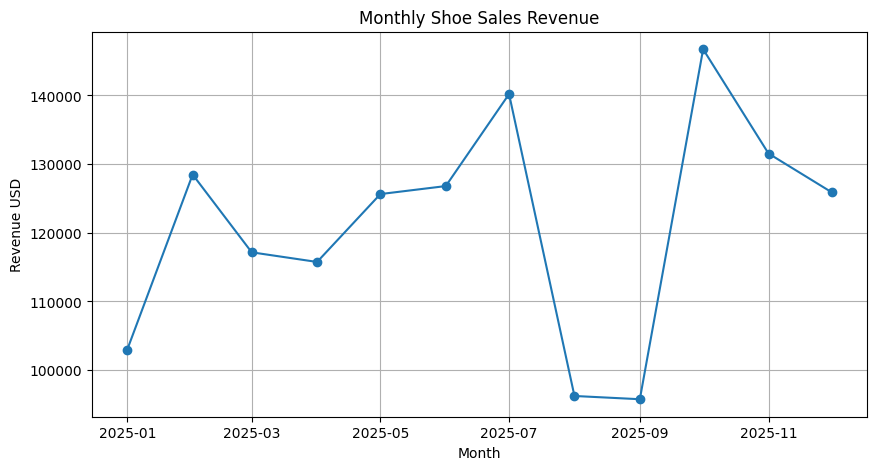

In [45]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")
plt.title("Monthly Shoe Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue USD")
plt.grid(True)
plt.show()

In [46]:
split_point = int(len(monthly_revenue) * 0.75)

train = monthly_revenue.iloc[:split_point]
test = monthly_revenue.iloc[split_point:]

In [47]:
best_order = None
best_aic = float("inf")

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()

                if model_fit.aic < best_aic:
                    best_aic = model_fit.aic
                    best_order = (p, d, q)

            except:
                pass

print("Best ARIMA Order:", best_order)


Best ARIMA Order: (0, 1, 0)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to conver

In [ ]:
arima_results = []

p_values = [0, 1, 2]
d_values = [0, 1]
q_values = [0, 1, 2]

for p in p_values:
    for d in d_values:
        for q in q_values:
            try:
                model = ARIMA(train, order=(p, d, q))
                model_fit = model.fit()

                prediction = model_fit.forecast(steps=len(test))
                prediction = pd.Series(prediction.values, index=test.index)
                prediction = prediction.clip(lower=0)

                squared_errors = (test.values - prediction.values) ** 2
                mse = np.mean(squared_errors)
                rmse = np.sqrt(mse)

                absolute_percentage_errors = np.abs((test.values - prediction.values) / test.values)
                mape = np.mean(absolute_percentage_errors) * 100

                arima_results.append({
                    "p": p,
                    "d": d,
                    "q": q,
                    "Order": (p, d, q),
                    "RMSE": rmse,
                    "MAPE": mape
                })

            except:
                pass

arima_results_df = pd.DataFrame(arima_results)
arima_results_df = arima_results_df.sort_values("RMSE")

arima_results_df


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,Order,RMSE,MAPE
2,0,0,2,"(0, 0, 2)",10699.112224,7.316063
12,2,0,0,"(2, 0, 0)",15207.428403,9.882143
8,1,0,2,"(1, 0, 2)",16542.125696,11.500902
14,2,0,2,"(2, 0, 2)",16963.360683,11.567389
7,1,0,1,"(1, 0, 1)",18876.068004,12.201338
13,2,0,1,"(2, 0, 1)",20079.847160,11.363796
0,0,0,0,"(0, 0, 0)",20179.589743,13.120820
6,1,0,0,"(1, 0, 0)",20997.965515,13.510597
1,0,0,1,"(0, 0, 1)",21428.924522,13.684826
17,2,1,2,"(2, 1, 2)",25493.524971,16.648510


In [ ]:
arima_model = ARIMA(train, order=(0, 0, 2))
arima_fit = arima_model.fit()

ARIMA Prediction:
2025-10-01    131491.048708
2025-11-01    123680.432160
2025-12-01    118854.178236
Freq: MS, dtype: float64
 ARIMA Lower Bound:
2025-10-01    110457.298853
2025-11-01    102940.875113
2025-12-01     91699.723937
Freq: MS, dtype: float64
ARIMA Upper Bound:
2025-10-01    152524.798563
2025-11-01    144419.989206
2025-12-01    146008.632535
Freq: MS, dtype: float64


In [ ]:
# get_forecast gives prediction and uncertainty interval.
arima_forecast_result = arima_fit.get_forecast(steps=len(test))

# Predicted values.
arima_prediction = arima_forecast_result.predicted_mean
arima_prediction = pd.Series(arima_prediction.values, index=test.index)
arima_prediction = arima_prediction.clip(lower=0)

# 95% confidence interval / prediction interval.
arima_confidence_interval = arima_forecast_result.conf_int(alpha=0.05)
arima_lower = pd.Series(arima_confidence_interval.iloc[:, 0].values, index=test.index).clip(lower=0)
arima_upper = pd.Series(arima_confidence_interval.iloc[:, 1].values, index=test.index).clip(lower=0)

print("Prediction:")
print(arima_prediction)
print("Lower Bound:")
print(arima_lower)
print("Upper Bound:")
print(arima_upper)

In [ ]:
arima_squared_errors = (test.values - arima_prediction.values) ** 2
arima_mse = np.mean(arima_squared_errors)
arima_rmse = np.sqrt(arima_mse)

arima_absolute_percentage_errors = np.abs((test.values - arima_prediction.values) / test.values)
arima_mape = np.mean(arima_absolute_percentage_errors) * 100

print("ARIMA RMSE:", arima_rmse)
print("ARIMA MAPE:", arima_mape)

ARIMA RMSE: 10699.11222431902
ARIMA MAPE: 7.31606269343914


In [52]:
sarima_model = SARIMAX(
    train,
    order=(0, 0, 1),
    seasonal_order=(1, 0, 1, 3),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

sarima_prediction = sarima_fit.forecast(steps=len(test))
sarima_prediction = pd.Series(sarima_prediction.values, index=test.index)
sarima_prediction = sarima_prediction.clip(lower=0)

sarima_prediction

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


2025-10-01    159390.116534
2025-11-01    113647.547267
2025-12-01    105453.169685
Freq: MS, dtype: float64

In [ ]:
sarima_squared_errors = (test.values - sarima_prediction.values) ** 2
sarima_mse = np.mean(sarima_squared_errors)
sarima_rmse = np.sqrt(sarima_mse)

sarima_absolute_percentage_errors = np.abs((test.values - sarima_prediction.values) / test.values)
sarima_mape = np.mean(sarima_absolute_percentage_errors) * 100

print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAPE:", sarima_mape)

SARIMA RMSE: 17303.2192557546
SARIMA MAPE: 12.822557412781558


In [54]:
prophet_train = train.reset_index()
prophet_train.columns = ["ds", "y"]

prophet_model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.01
    )

prophet_model.fit(prophet_train)

prophet_future = pd.DataFrame({"ds": test.index})
prophet_forecast = prophet_model.predict(prophet_future)

prophet_prediction = pd.Series(prophet_forecast["yhat"].values, index=test.index)
prophet_prediction = prophet_prediction.clip(lower=0)

print(prophet_prediction)


16:33:09 - cmdstanpy - INFO - Chain [1] start processing
16:33:09 - cmdstanpy - INFO - Chain [1] done processing


2025-10-01    110749.441656
2025-11-01    109565.595273
2025-12-01    108419.937483
Freq: MS, dtype: float64


In [ ]:
prophet_squared_errors = (test.values - prophet_prediction.values) ** 2
prophet_mse = np.mean(prophet_squared_errors)
prophet_rmse = np.sqrt(prophet_mse)

prophet_absolute_percentage_errors = np.abs((test.values - prophet_prediction.values) / test.values)
prophet_mape = np.mean(prophet_absolute_percentage_errors) * 100

print("Prophet RMSE:", prophet_rmse)
print("Prophet MAPE:", prophet_mape)

Prophet RMSE: 26346.945622940555
Prophet MAPE: 18.36771638580776


In [56]:
model_results = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA", "Prophet"],
    "RMSE": [arima_rmse, sarima_rmse, prophet_rmse],
    "MAPE": [arima_mape, sarima_mape, prophet_mape]
})

model_results = model_results.sort_values("RMSE")
model_results

,Model,RMSE,MAPE
0,ARIMA,10699.112224,7.316063
1,SARIMA,17303.219256,12.822557
2,Prophet,26346.945623,18.367716


In [ ]:
best_model_name = "ARIMA"
best_prediction = arima_prediction

print("Best model:", best_model_name)
print("Best RMSE:", arima_rmse)
print("Best MAPE:", arima_mape)

Best model: ARIMA
Best RMSE: 10699.11222431902
Best MAPE: 7.31606269343914


In [58]:
uncertainty_table = pd.DataFrame({
    "Date": test.index,
    "Actual_Revenue_USD": test.values,
    "Predicted_Revenue_USD": arima_prediction.values,
    "Lower_Bound_95": arima_lower.values,
    "Upper_Bound_95": arima_upper.values
})

uncertainty_table

,Date,Actual_Revenue_USD,Predicted_Revenue_USD,Lower_Bound_95,Upper_Bound_95
0,2025-10-01,146726.46,131491.048708,110457.298853,152524.798563
1,2025-11-01,131542.53,123680.432160,102940.875113,144419.989206
2,2025-12-01,125888.57,118854.178236,91699.723937,146008.632535


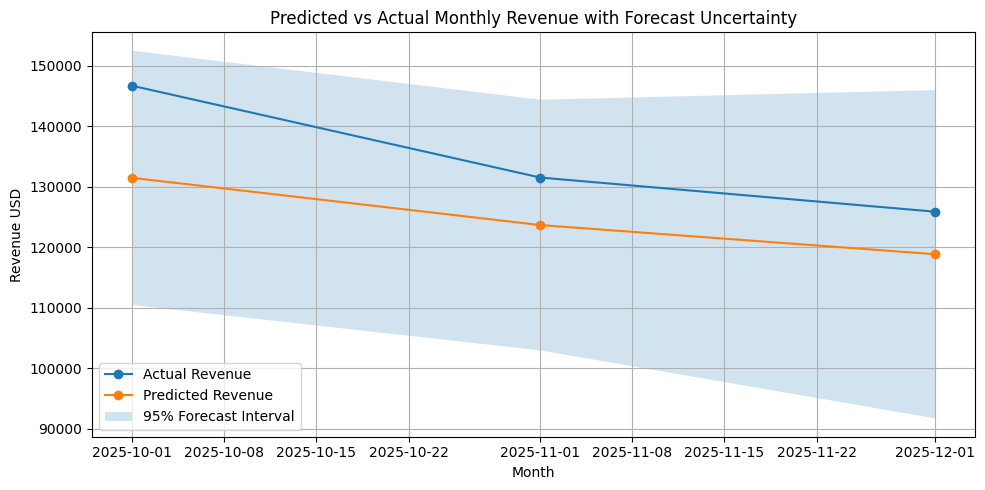

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test.index, test.values, marker="o", label="Actual Revenue")
plt.plot(best_prediction.index, best_prediction.values, marker="o", label="Predicted Revenue")

plt.fill_between(test.index, arima_lower.values, arima_upper.values, alpha=0.2, label="95% Forecast Interval")

plt.title("Predicted vs Actual Monthly Revenue with Forecast Uncertainty")
plt.xlabel("Month")
plt.ylabel("Revenue USD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [62]:
prediction_table = pd.DataFrame({
    "Date": test.index,
    "Actual_Revenue_USD": test.values,
    "Predicted_Revenue_USD": best_prediction.values
})

prediction_table["Error"] = prediction_table["Actual_Revenue_USD"] - prediction_table["Predicted_Revenue_USD"]
prediction_table["Absolute_Percentage_Error"] = abs(prediction_table["Error"] / prediction_table["Actual_Revenue_USD"]) * 100

prediction_table

,Date,Actual_Revenue_USD,Predicted_Revenue_USD,Error,Absolute_Percentage_Error
0,2025-10-01,146726.46,131491.048708,15235.411292,10.383547
1,2025-11-01,131542.53,123680.432160,7862.097840,5.976849
2,2025-12-01,125888.57,118854.178236,7034.391764,5.587792


In [63]:
final_arima_model = ARIMA(monthly_revenue, order=(0, 0, 2))
final_arima_fit = final_arima_model.fit()

# Forecast next 3 months with uncertainty.
future_forecast_result = final_arima_fit.get_forecast(steps=3)
future_prediction = future_forecast_result.predicted_mean
future_confidence_interval = future_forecast_result.conf_int(alpha=0.05)

future_dates = pd.date_range(
    start=monthly_revenue.index.max() + pd.DateOffset(months=1),
    periods=3,
    freq="MS"
)

future_forecast = pd.DataFrame({
    "Date": future_dates,
    "Forecast_Revenue_USD": future_prediction.values,
    "Lower_Bound_95": future_confidence_interval.iloc[:, 0].values,
    "Upper_Bound_95": future_confidence_interval.iloc[:, 1].values
})

future_forecast["Forecast_Revenue_USD"] = future_forecast["Forecast_Revenue_USD"].clip(lower=0)
future_forecast["Lower_Bound_95"] = future_forecast["Lower_Bound_95"].clip(lower=0)
future_forecast["Upper_Bound_95"] = future_forecast["Upper_Bound_95"].clip(lower=0)

future_forecast

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Date,Forecast_Revenue_USD,Lower_Bound_95,Upper_Bound_95
0,2026-01-01,120773.265759,99950.187112,141596.344406
1,2026-02-01,110600.291473,89777.212826,131423.370120
2,2026-03-01,121018.685368,93472.341553,148565.029184


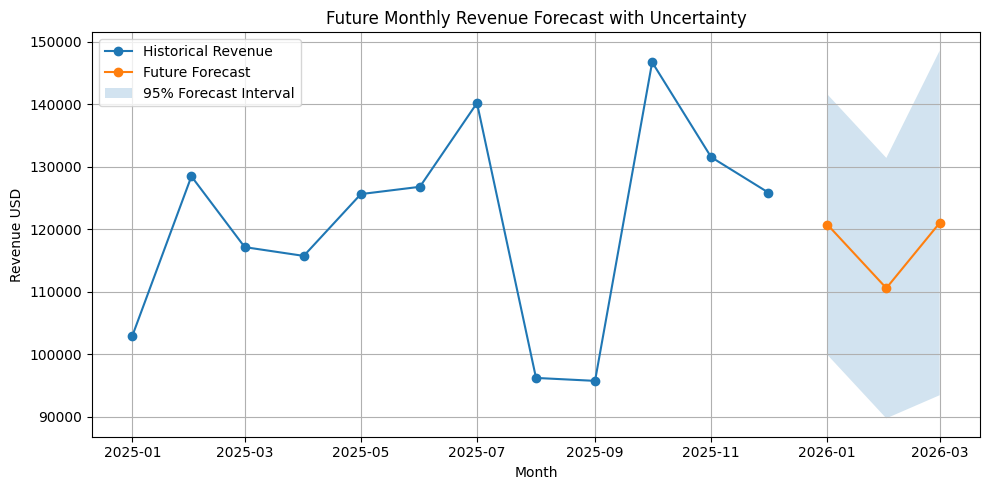

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", label="Historical Revenue")
plt.plot(future_forecast["Date"], future_forecast["Forecast_Revenue_USD"], marker="o", label="Future Forecast")

plt.fill_between(
    future_forecast["Date"],
    future_forecast["Lower_Bound_95"],
    future_forecast["Upper_Bound_95"],
    alpha=0.2,
    label="95% Forecast Interval"
)

plt.title("Future Monthly Revenue Forecast with Uncertainty")
plt.xlabel("Month")
plt.ylabel("Revenue USD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
